In [1]:
from pathlib import Path
import sys
import shutil
import importlib
import json
import pandas as pd
import numpy as np
import papermill as pm
from scipy.stats import qmc


RUN_CONFIGS = [

    {
        "run_id": "ETHlib_default_occ",
        "rc_simulator": "ETHlib",
        "occ_csv": Path("_data/default_occ.csv"),
        "occ_col": None,
        "model_name": "5R1C",
    },
    {
        "run_id": "ETHlib_ONSITE_occ",
        "rc_simulator": "ETHlib",
        "occ_csv": Path("_data/ONSITE_occ.csv"),
        "occ_col": None,
        "model_name": "5R1C",
    },
    {
        "run_id": "ETHlib_bldg_LoD_Y",
        "rc_simulator": "ETHlib",
        "occ_csv": Path("_data/bldg_LoD.csv"),
        "occ_col": "Y",
        "model_name": "5R1C",
    },
    {
        "run_id": "ETHlib_3R2C_default_occ",
        "rc_simulator": "ETHlib_3R2C",
        "occ_csv": Path("_data/default_occ.csv"),
        "occ_col": None,
        "model_name": "3R2C",
    },
    {
        "run_id": "ETHlib_3R2C_ONSITE_occ",
        "rc_simulator": "ETHlib_3R2C",
        "occ_csv": Path("_data/ONSITE_occ.csv"),
        "occ_col": None,
        "model_name": "3R2C",
    },
    {
        "run_id": "ETHlib_3R2C_bldg_LoD_Y",
        "rc_simulator": "ETHlib_3R2C",
        "occ_csv": Path("_data/bldg_LoD.csv"),
        "occ_col": "Y",
        "model_name": "3R2C",
    },

]

In [2]:
# ============================================================
# GLOBAL settings
# ============================================================

BASE_DATE = "JUN11"

controller_mode = "occupancy"
start = "2023-01-20 00:00"
end = "2023-03-17 23:00"
N = 80

base_run_dir = Path(f"_json/_run/{BASE_DATE}")
base_oat_json = base_run_dir / "OAT.json"
base_default_json = Path("_json/default_params.json")

meter_path = Path("_data/Metering_ISO.csv")

assert base_run_dir.exists(), f"Missing folder: {base_run_dir}"
assert base_oat_json.exists(), f"Missing file: {base_oat_json}"
assert base_default_json.exists(), f"Missing file: {base_default_json}"


# ============================================================
# 2. Import helpers
# ============================================================
def find_posterior_file(run_dir):
    run_dir = Path(run_dir)

    matches = list(run_dir.rglob("posterior_rand10_from_topfrac.csv"))

    if not matches:
        raise FileNotFoundError(
            f"No posterior_rand10_from_topfrac.csv found under {run_dir}. "
            "Check whether 1_PLOT_map.ipynb saved the posterior file using DATE=run_label."
        )

    matches = sorted(matches, key=lambda p: p.stat().st_mtime, reverse=True)

    return matches[0]

from pathlib import Path
import sys
import importlib


def is_inside(path, root):
    try:
        path = Path(path).resolve()
        root = Path(root).resolve()
        return root == path or root in path.parents
    except Exception:
        return False


def activate_rc_library(rc_simulator):
    rc_root = Path(rc_simulator).resolve()

    all_rc_roots = [
        Path("ETHlib").resolve(),
        Path("ETHlib_3R2C").resolve(),
    ]

    # Remove any module loaded from either RC library folder
    for module_name, module in list(sys.modules.items()):
        module_file = getattr(module, "__file__", None)

        if module_file is None:
            continue

        if any(is_inside(module_file, root) for root in all_rc_roots):
            sys.modules.pop(module_name, None)

    # Also remove common top-level module names
    for module_name in [
        "_",
        "_BR_",
        "_zone_",
        "building_physics",
        "supply_system",
        "emission_system",
        "radiation",
        "window",
        "building",
        "lighting",
        "occupancy",
        "ventilation",
    ]:
        sys.modules.pop(module_name, None)

    # Remove both RC folders from sys.path
    clean_sys_path = []

    for p in sys.path:
        try:
            if any(Path(p).resolve() == root for root in all_rc_roots):
                continue
        except Exception:
            pass

        clean_sys_path.append(p)

    sys.path = clean_sys_path

    # Add selected library first
    sys.path.insert(0, str(rc_root))
    importlib.invalidate_caches()

    rc_tools = importlib.import_module("_")
    br = importlib.import_module("_BR_")
    zone = importlib.import_module("_zone_")
    supply_system = importlib.import_module("supply_system")
    emission_system = importlib.import_module("emission_system")

    return rc_tools, br, zone, supply_system, emission_system

def get_rc_func(name, rc_tools, br):
    for module in [rc_tools, br]:
        if hasattr(module, name):
            print(f"[INFO] Using {name} from module: {module.__name__}")
            return getattr(module, name)

    available = {
        rc_tools.__name__: [x for x in dir(rc_tools) if name.lower() in x.lower()],
        br.__name__: [x for x in dir(br) if name.lower() in x.lower()],
    }

    raise AttributeError(
        f"Could not find {name!r} in the active RC library. "
        f"Similar names: {available}"
    )


def prepare_run_folder(run_label):
    run_dir = Path(f"_json/_run/{run_label}")
    run_dir.mkdir(parents=True, exist_ok=True)

    copied_oat_json = run_dir / "OAT.json"
    copied_default_json = run_dir / "default_params.json"

    shutil.copy2(base_oat_json, copied_oat_json)
    shutil.copy2(base_default_json, copied_default_json)

    return run_dir, copied_oat_json, copied_default_json


def read_occ_profile(path, col=None):
    path = Path(path)

    if col is None:
        occ = pd.read_csv(path, usecols=[0])
    else:
        occ = pd.read_csv(path, usecols=[col])

    occ = occ.iloc[:8760].reset_index(drop=True).copy()
    occ.columns = ["People"]

    return occ


def make_case(cfg, copied_default_json):
    rc_tools, br, zone, supply_system, emission_system = activate_rc_library(
        cfg["rc_simulator"]
    )

    case = br.RCCase(
        year=2023,
        loc_json=Path("_json/location_params.json"),
        geo_json=Path("_json/geo_params.json"),
        default_json=copied_default_json,
        epw_path=Path("../src/_base/epw/ED-TMYx.2023.epw"),
        occupancy_profile_csv=Path("_data/default_occ.csv"),
        Zone=zone.DebugZone,
        supply_system=supply_system,
        emission_system=emission_system,
    )

    occ = read_occ_profile(
        path=cfg["occ_csv"],
        col=cfg["occ_col"],
    )

    case.occupancy_profile = occ
    case.electricity_profile = occ.copy()

    rc_funcs = {
        "run_model_case": get_rc_func("run_model_case", rc_tools, br),
        "load_meter_heating": get_rc_func("load_meter_heating", rc_tools, br),
        "show_progress": get_rc_func("show_progress", rc_tools, br),
    }

    return case, rc_funcs


# ============================================================
# 3. LHS and calibration helpers
# ============================================================

def make_lhs_samples_from_uq_json(uq_json_path, N=80, save_csv=True):
    uq_json_path = Path(uq_json_path)

    with open(uq_json_path, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    seed = uq_config["seed"]
    params = uq_config["parameters"]

    param_names = list(params.keys())

    sampler = qmc.LatinHypercube(
        d=len(param_names),
        seed=seed,
    )

    lhs_unit = sampler.random(n=N)

    samples = pd.DataFrame(
        index=range(N),
        columns=param_names,
        dtype=float,
    )

    for i, name in enumerate(param_names):
        lower = params[name]["lower"]
        upper = params[name]["upper"]
        samples[name] = lower + lhs_unit[:, i] * (upper - lower)

    samples.index = [f"sample_{i+1:03d}" for i in range(N)]

    if save_csv:
        output_path = uq_json_path.parent / "LHS_samples.csv"
        samples.to_csv(output_path)
        print(f"[INFO] Saved LHS samples to: {output_path}")

    return samples


def run_lhs_samples(
    lhs_samples,
    case,
    rc_funcs,
    controller_mode="occupancy",
):
    results = {}
    euis = {}

    for sample_id, row in rc_funcs["show_progress"](
        lhs_samples.iterrows(),
        total=len(lhs_samples),
        desc="Running LHS samples",
        unit="sample",
    ):
        sampled_params = row.to_dict()

        res, eui, _ = rc_funcs["run_model_case"](
            case=case,
            sampled_params=sampled_params,
            controller_mode=controller_mode,
        )

        results[sample_id] = res
        euis[sample_id] = eui

    eui_df = pd.DataFrame(euis).T

    return results, eui_df


def save_bayesian_calibration_files(
    lhs_samples,
    lhs_results,
    meter_series,
    variable="HeatingEnergy",
    freq="D",
    start=None,
    end=None,
    output_dir=None,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    TT = lhs_samples.copy()

    def prepare_series(series):
        series = series.copy()

        if start is not None or end is not None:
            series = series.loc[start:end]

        if freq is not None:
            series = series.resample(freq).sum()

        return series

    Y = pd.DataFrame({
        sample_id: prepare_series(res[variable])
        for sample_id, res in lhs_results.items()
    })

    obs = prepare_series(meter_series)
    obs.name = "obs"

    common_index = obs.index.intersection(Y.index)

    obs = obs.loc[common_index]
    Y = Y.loc[common_index]

    TT.to_csv(output_dir / "TT.csv", index=False)
    Y.to_csv(output_dir / "Y.csv", index=False)
    obs.to_csv(output_dir / "obs.csv", index=False)

    print(f"[INFO] Saved Bayesian calibration files to: {output_dir}")
    print(f"[INFO] Period: {obs.index.min()} to {obs.index.max()}")
    print(f"[INFO] TT shape:  {TT.shape}")
    print(f"[INFO] Y shape:   {Y.shape}")
    print(f"[INFO] obs shape: {obs.shape}")

    return TT, Y, obs


# ============================================================
# 4. ECM helpers
# ============================================================

def make_ecm_specs(case):
    default_win = case.default_params["window_opening_ach"]

    return {
        "Baseline": {},

        "ECM-1_setpoint_19C": {
            "t_set_heating": 19.5,
        },

        "ECM-2_reschedule_8_8_8": {
            "heating_schedule_mode": "8_8_8",
        },

        "ECM-3_setpoint_19C_reschedule_8_8_8": {
            "t_set_heating": 19.5,
            "heating_schedule_mode": "8_8_8",
        },

        "ECM-4_setpoint_19C_default_infiltration": {
            "t_set_heating": 19.5,
            "window_opening_ach": default_win,
        },

        "ECM-5_reschedule_8_8_8_default_infiltration": {
            "heating_schedule_mode": "8_8_8",
            "window_opening_ach": default_win,
        },
    }


def run_posterior_ecm_samples(
    posterior_TT,
    case,
    rc_funcs,
    extra_params=None,
    controller_mode="occupancy",
):
    results = {}
    euis = {}

    if extra_params is None:
        extra_params = {}

    for sample_id, row in rc_funcs["show_progress"](
        posterior_TT.iterrows(),
        total=len(posterior_TT),
        desc="Running posterior samples",
        unit="sample",
    ):
        sampled_params = row.to_dict()
        sampled_params.update(extra_params)

        res, eui, _ = rc_funcs["run_model_case"](
            case=case,
            sampled_params=sampled_params,
            controller_mode=controller_mode,
        )

        results[sample_id] = res
        euis[sample_id] = eui

    eui_df = pd.DataFrame(euis).T

    return results, eui_df


def run_ecm_suite(
    posterior_TT,
    ecm_specs,
    case,
    rc_funcs,
    controller_mode="occupancy",
):
    all_results = {}
    all_euis = {}

    for ecm_name, extra_params in ecm_specs.items():
        print(f"[INFO] Running ECM: {ecm_name}")

        results, eui_df = run_posterior_ecm_samples(
            posterior_TT=posterior_TT,
            case=case,
            rc_funcs=rc_funcs,
            extra_params=extra_params,
            controller_mode=controller_mode,
        )

        all_results[ecm_name] = results
        all_euis[ecm_name] = eui_df

    return all_results, all_euis


# ============================================================
# 5. Main six-run workflow
# ============================================================
# ============================================================
# 4. Generate one shared LHS set for all RC runs
# ============================================================

master_lhs_samples = make_lhs_samples_from_uq_json(
    uq_json_path=base_oat_json,
    N=N,
    save_csv=False,
)

master_lhs_path = base_run_dir / f"LHS_samples_MASTER_N{N}.csv"
master_lhs_samples.to_csv(master_lhs_path)

print(f"[INFO] Saved shared master LHS samples to: {master_lhs_path}")
all_run_outputs = {}

for cfg in RUN_CONFIGS:
    run_id = cfg["run_id"]
    run_label = f"{BASE_DATE}__{run_id}"

    print("\n" + "=" * 90)
    print(f"[INFO] Starting run: {run_label}")
    print("=" * 90)

    # --------------------------------------------------------
    # Folder and config copies
    # --------------------------------------------------------

    run_dir, uq_json_path, copied_default_json = prepare_run_folder(run_label)

    # --------------------------------------------------------
    # Activate library and build case
    # --------------------------------------------------------

    case, rc_funcs = make_case(
        cfg=cfg,
        copied_default_json=copied_default_json,
    )
    import inspect

    print("[CHECK] Zone file:", inspect.getfile(case.Zone))
    print("[CHECK] run_model_case:", inspect.getfile(rc_funcs["run_model_case"]))
    print("[CHECK] solve_energy signature:")
    print(inspect.signature(case.Zone.solve_energy))
    # --------------------------------------------------------
    # Meter data
    # --------------------------------------------------------

    meter_daily = rc_funcs["load_meter_heating"](
        meter_path,
        "Main Heating",
        case.geometry["FLOOR_AREA"],
        "D",
    )

    meter_hourly = rc_funcs["load_meter_heating"](
        meter_path,
        "Main Heating",
        case.geometry["FLOOR_AREA"],
        "h",
    )

    # --------------------------------------------------------
    # LHS simulations
    # --------------------------------------------------------

    lhs_samples = master_lhs_samples.copy()

    lhs_path = run_dir / "LHS_samples.csv"
    lhs_samples.to_csv(lhs_path)

    print(f"[INFO] Reused shared LHS samples: {lhs_path}")

    lhs_results, lhs_eui_df = run_lhs_samples(
        lhs_samples=lhs_samples,
        case=case,
        rc_funcs=rc_funcs,
        controller_mode=controller_mode,
    )

    # --------------------------------------------------------
    # Save Calibro input files
    # --------------------------------------------------------

    TT, Y, obs = save_bayesian_calibration_files(
        lhs_samples=lhs_samples,
        lhs_results=lhs_results,
        meter_series=meter_hourly,
        variable="HeatingEnergy",
        freq="D",
        start=start,
        end=end,
        output_dir=run_dir / "BC",
    )

    pm.execute_notebook(
        "1_CALIBRO.ipynb",
        f"{run_label}__CALIBRO.ipynb",
        parameters={
            "DATE": run_label,
            "START_DATE": start,
            "END_DATE": end,
        },
    )

    # --------------------------------------------------------
    # Run posterior selection / mapping notebook
    # This notebook should create posterior_rand10_from_topfrac.csv
    # --------------------------------------------------------

    pm.execute_notebook(
        "1_PLOT_map.ipynb",
        f"{run_label}__PLOT_map.ipynb",
        parameters={
            "DATE": run_label,
            "START_DATE": start,
            "END_DATE": end,
        },
    )

    # --------------------------------------------------------
    # Read posterior samples generated by 1_PLOT_map.ipynb
    # --------------------------------------------------------

    posterior_TT_path = find_posterior_file(run_dir)

    print(f"[INFO] Using posterior file: {posterior_TT_path}")

    posterior_TT = pd.read_csv(posterior_TT_path)

    ecm_specs = make_ecm_specs(case)

    all_results, all_euis = run_ecm_suite(
        posterior_TT=posterior_TT,
        ecm_specs=ecm_specs,
        case=case,
        rc_funcs=rc_funcs,
        controller_mode=controller_mode,
    )

    # --------------------------------------------------------
    # Export outcomes
    # --------------------------------------------------------

    sys.modules.pop("__ot__", None)
    export_module = importlib.import_module("__ot__")

    tables = export_module.export_posterior_outcomes(
        all_results=all_results,
        meter_daily=meter_daily,
        start_date=start,
        end_date=end,
        experiment_id=run_label,
        engine=cfg["rc_simulator"],
        model_name=cfg["model_name"],
        controller_mode=controller_mode,
        baseline_name="Baseline",
        variable="HeatingEnergy",
        out_dir=run_dir / "_outcome",
    )

    # --------------------------------------------------------
    # Keep lightweight run records
    # --------------------------------------------------------

    all_run_outputs[run_label] = {
        "cfg": cfg,
        "run_dir": run_dir,
        "lhs_samples": lhs_samples,
        "lhs_eui_df": lhs_eui_df,
        "posterior_TT": posterior_TT,
        "all_euis": all_euis,
        "tables": tables,
    }

    print(f"[INFO] Finished run: {run_label}")

[INFO] Saved shared master LHS samples to: _json/_run/JUN11/LHS_samples_MASTER_N80.csv

[INFO] Starting run: JUN11__ETHlib_default_occ
[INFO] Using run_model_case from module: _BR_
[INFO] Using load_meter_heating from module: _BR_
[INFO] Using show_progress from module: _
[CHECK] Zone file: /Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/ETHlib/_zone_.py
[CHECK] run_model_case: /Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/ETHlib/_BR_.py
[CHECK] solve_energy signature:
(self, internal_gains, solar_gains, t_out, t_m_prev)
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
[INFO] Reused shared LHS samples: _json/_run/JUN11__ETHlib_default_occ/LHS_samples.csv


Running LHS samples:   0%|          | 0/80 [00:00<?, ?sample/s]

Passed unknown parameter: DATE
Passed unknown parameter: START_DATE
Passed unknown parameter: END_DATE
Input notebook does not contain a cell with tag 'parameters'


[INFO] Saved Bayesian calibration files to: _json/_run/JUN11__ETHlib_default_occ/BC
[INFO] Period: 2023-01-20 00:00:00 to 2023-03-17 00:00:00
[INFO] TT shape:  (80, 4)
[INFO] Y shape:   (57, 80)
[INFO] obs shape: (57,)


Executing:   0%|          | 0/4 [00:00<?, ?cell/s]

...

Running posterior samples:   0%|          | 0/10 [00:00<?, ?sample/s]

[INFO] Running ECM: ECM-5_reschedule_8_8_8_default_infiltration


Running posterior samples:   0%|          | 0/10 [00:00<?, ?sample/s]

/Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/_.py:225: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample(freq)
/Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/_.py:225: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample(freq)
/Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/_.py:225: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample(freq)
/Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/_.py:225: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample(freq)
/Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/_.py:225: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample(freq)
/Users/rui.bo/Desktop/BASE/1_phd/Y3/RC_br/_.py:225: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resampl

[INFO] Finished run: JUN11__ETHlib_3R2C_bldg_LoD_Y


# Previsualisation

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


BASE_DATE = "JUN11"
ROOT = Path("_json/_run")


def parse_run_label(experiment_id):
    run_id = experiment_id.split("__", 1)[1]

    if run_id.startswith("ETHlib_3R2C_"):
        lib = "ETHlib_3R2C"
        model_complexity = "3R2C"
        data_source = run_id.replace("ETHlib_3R2C_", "")

    elif run_id.startswith("ETHlib_"):
        lib = "ETHlib"
        model_complexity = "5R1C"
        data_source = run_id.replace("ETHlib_", "")

    else:
        raise ValueError(f"Cannot parse run label: {experiment_id}")

    data_label = {
        "default_occ": "Default occupancy",
        "ONSITE_occ": "On-site occupancy",
        "bldg_LoD_Y": "LoD-Y occupancy",
    }.get(data_source, data_source)

    return lib, model_complexity, data_source, data_label


def collect_outcomes(base_date="JUN11"):
    metric_tables = []
    saving_tables = []

    for run_dir in sorted(ROOT.glob(f"{base_date}__*")):
        experiment_id = run_dir.name
        outcome_dir = run_dir / "_outcome" / experiment_id

        metric_path = outcome_dir / "baseline_metrics_daily.csv"
        saving_path = outcome_dir / "ecm_savings_daily.csv"

        if not metric_path.exists():
            print(f"[WARN] Missing: {metric_path}")
            continue

        if not saving_path.exists():
            print(f"[WARN] Missing: {saving_path}")
            continue

        lib, model_complexity, data_source, data_label = parse_run_label(
            experiment_id
        )

        metric_df = pd.read_csv(metric_path)
        saving_df = pd.read_csv(saving_path)

        for df in [metric_df, saving_df]:
            df["run_label"] = experiment_id
            df["lib"] = lib
            df["model_complexity"] = model_complexity
            df["data_source"] = data_source
            df["data_label"] = data_label

        metric_tables.append(metric_df)
        saving_tables.append(saving_df)

    metrics_all = pd.concat(metric_tables, ignore_index=True)
    savings_all = pd.concat(saving_tables, ignore_index=True)

    data_order = [
        "Default occupancy",
        "On-site occupancy",
        "LoD-Y occupancy",
    ]

    model_order = [
        "3R2C",
        "5R1C",
    ]

    metrics_all["data_label"] = pd.Categorical(
        metrics_all["data_label"],
        categories=data_order,
        ordered=True,
    )

    savings_all["data_label"] = pd.Categorical(
        savings_all["data_label"],
        categories=data_order,
        ordered=True,
    )

    metrics_all["model_complexity"] = pd.Categorical(
        metrics_all["model_complexity"],
        categories=model_order,
        ordered=True,
    )

    savings_all["model_complexity"] = pd.Categorical(
        savings_all["model_complexity"],
        categories=model_order,
        ordered=True,
    )

    return metrics_all, savings_all


metrics_all, savings_all = collect_outcomes(BASE_DATE)

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/172689144.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


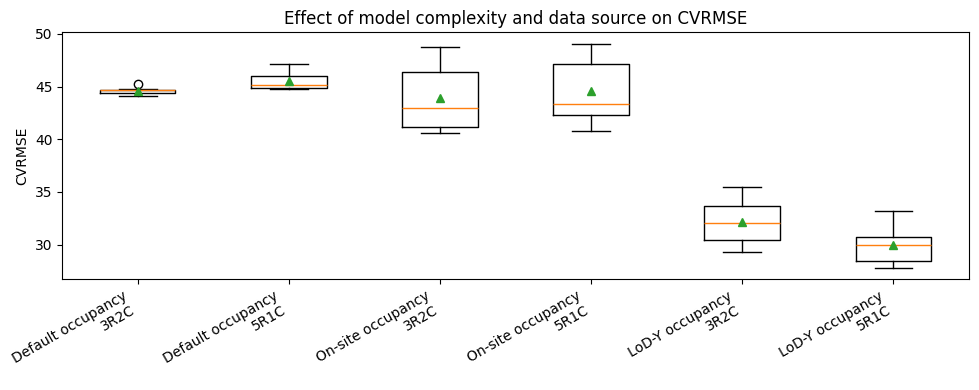

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/172689144.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


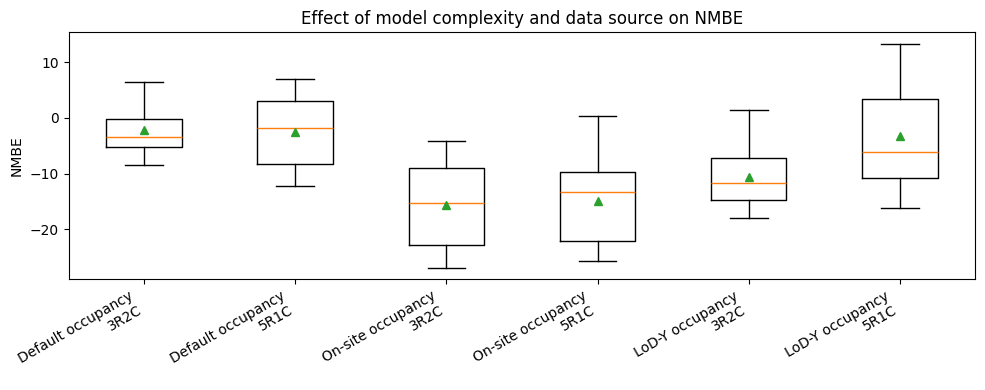

In [4]:
def plot_calibration_metric(metrics_all, metric="cvrmse"):
    plot_df = metrics_all.copy()

    groups = []
    labels = []

    for data_label in plot_df["data_label"].cat.categories:
        for model_complexity in plot_df["model_complexity"].cat.categories:
            sub = plot_df[
                (plot_df["data_label"] == data_label)
                & (plot_df["model_complexity"] == model_complexity)
            ]

            if len(sub) == 0:
                continue

            groups.append(sub[metric].dropna())
            labels.append(f"{data_label}\n{model_complexity}")

    plt.figure(figsize=(10, 4))
    plt.boxplot(groups, labels=labels, showmeans=True)
    plt.ylabel(metric.upper())
    plt.xticks(rotation=30, ha="right")
    plt.title(f"Effect of model complexity and data source on {metric.upper()}")
    plt.tight_layout()
    plt.show()


plot_calibration_metric(metrics_all, metric="cvrmse")
plot_calibration_metric(metrics_all, metric="nmbe")

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


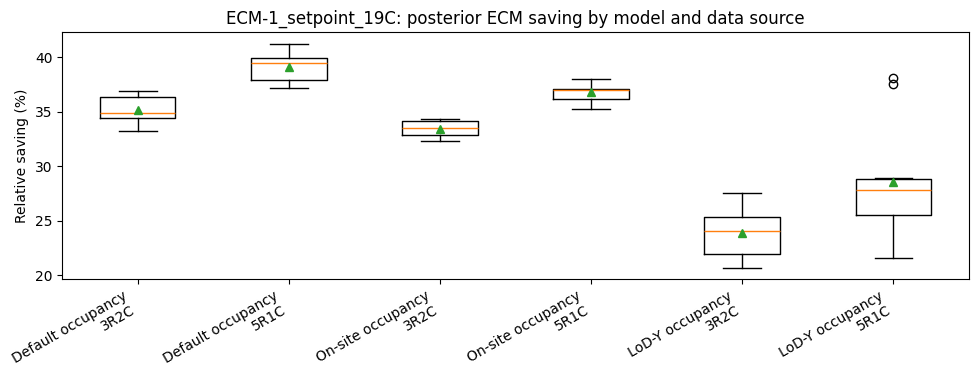

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


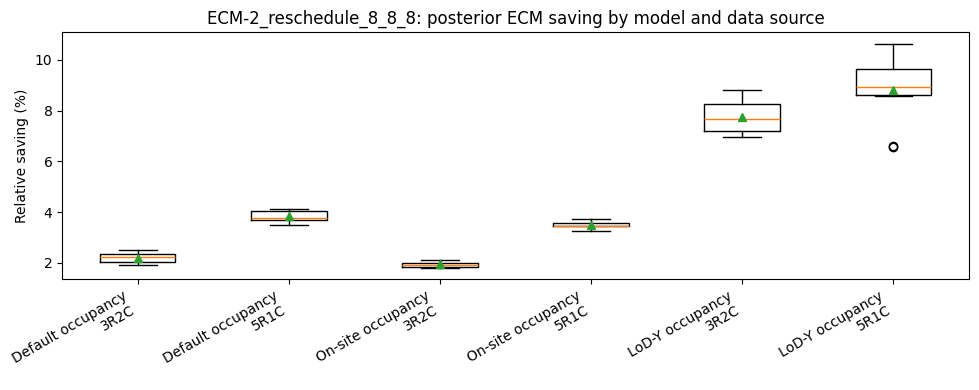

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


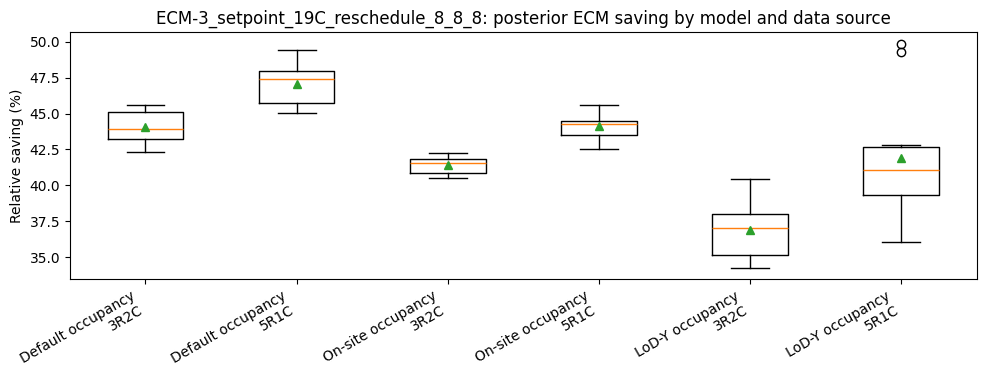

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


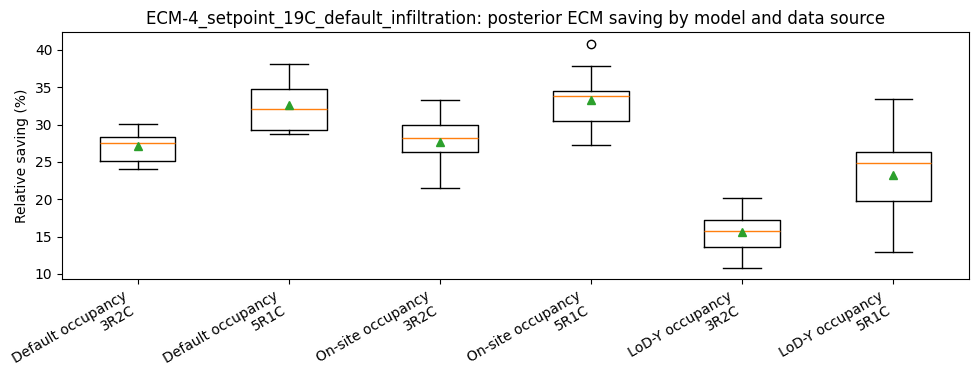

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


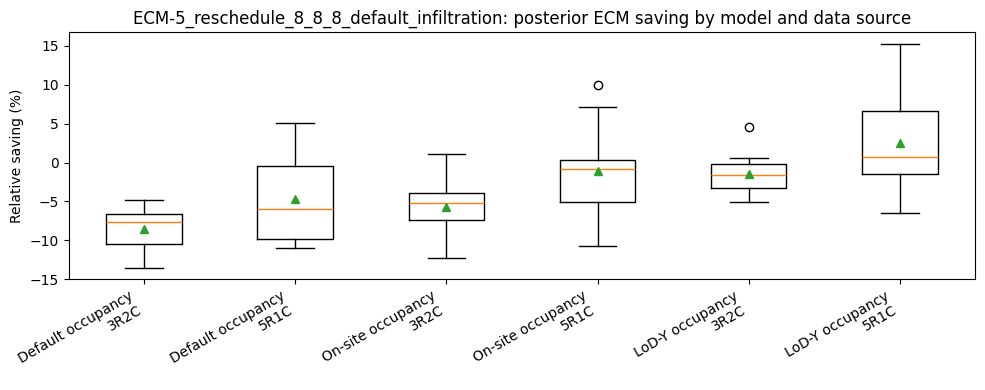

In [5]:
def plot_ecm_savings_by_group(
    savings_all,
    ecm,
    saving_col="saving_rel",
):
    plot_df = savings_all[savings_all["ecm"] == ecm].copy()

    groups = []
    labels = []

    for data_label in plot_df["data_label"].cat.categories:
        for model_complexity in plot_df["model_complexity"].cat.categories:
            sub = plot_df[
                (plot_df["data_label"] == data_label)
                & (plot_df["model_complexity"] == model_complexity)
            ]

            if len(sub) == 0:
                continue

            groups.append(sub[saving_col].dropna())
            labels.append(f"{data_label}\n{model_complexity}")

    plt.figure(figsize=(10, 4))
    plt.boxplot(groups, labels=labels, showmeans=True)

    if saving_col == "saving_rel":
        plt.ylabel("Relative saving (%)")
    else:
        plt.ylabel("Absolute saving")

    plt.xticks(rotation=30, ha="right")
    plt.title(f"{ecm}: posterior ECM saving by model and data source")
    plt.tight_layout()
    plt.show()


for ecm in savings_all["ecm"].unique():
    plot_ecm_savings_by_group(
        savings_all=savings_all,
        ecm=ecm,
        saving_col="saving_rel",
    )

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


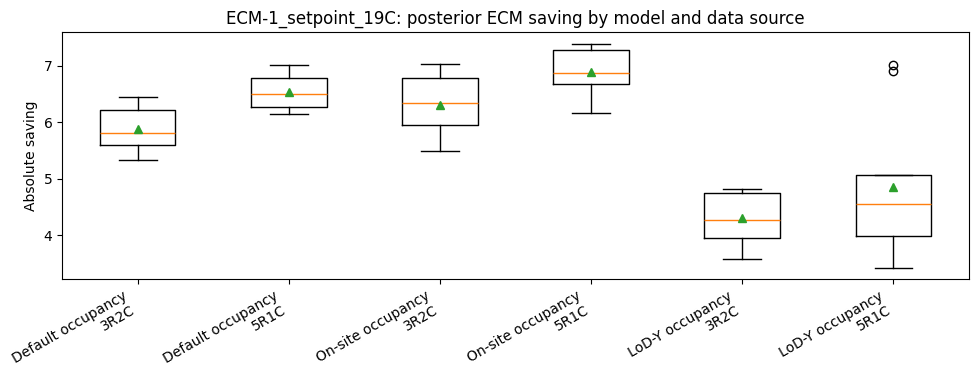

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


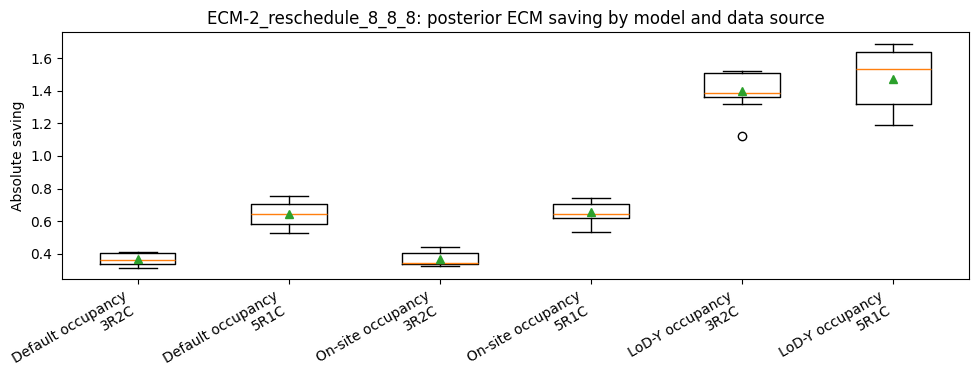

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


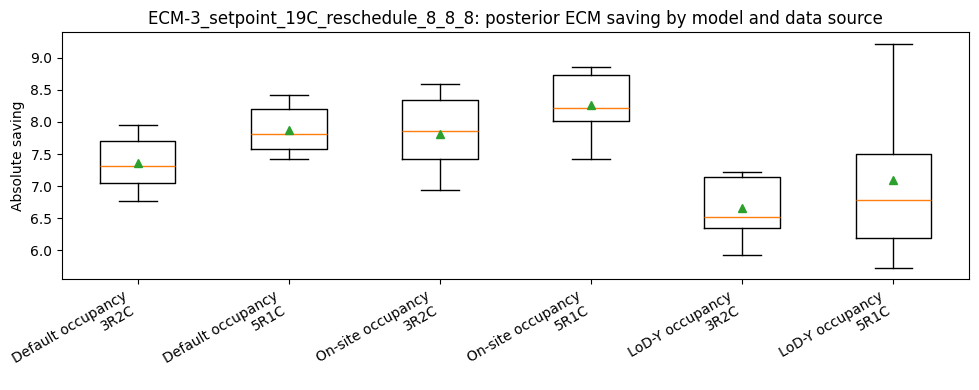

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


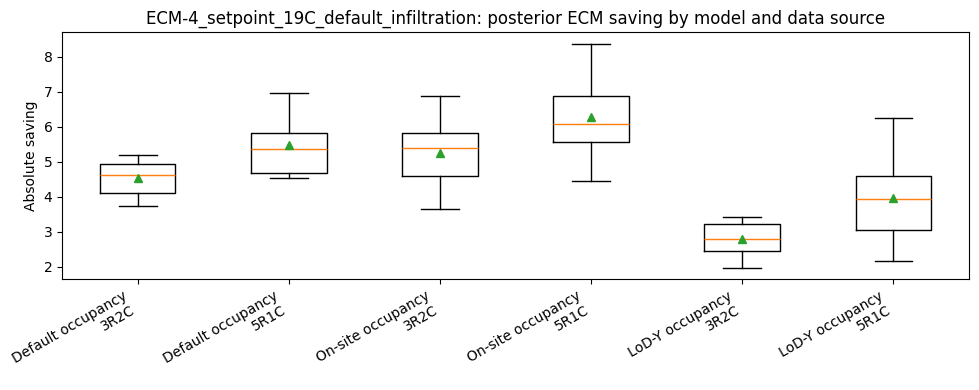

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_56291/4149222009.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


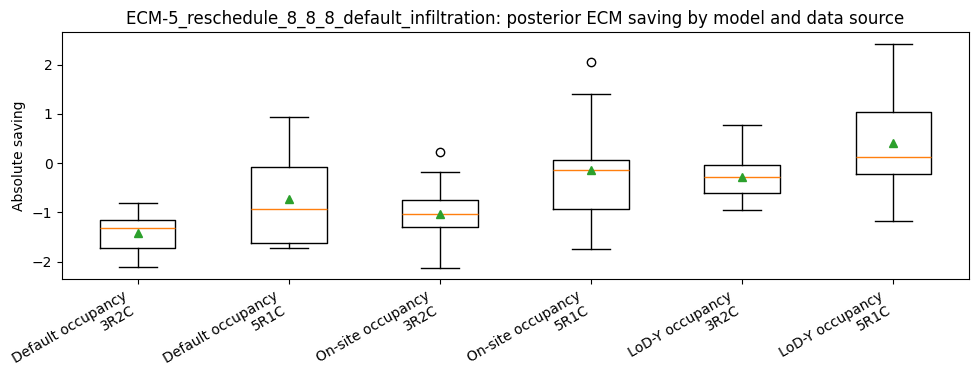

In [6]:
for ecm in savings_all["ecm"].unique():
    plot_ecm_savings_by_group(
        savings_all=savings_all,
        ecm=ecm,
        saving_col="saving_abs",
    )

In [7]:
calibration_summary = (
    metrics_all
    .groupby(["data_label", "model_complexity"], observed=True)
    .agg(
        n_samples=("sample_id", "nunique"),
        cvrmse_mean=("cvrmse", "mean"),
        cvrmse_median=("cvrmse", "median"),
        cvrmse_std=("cvrmse", "std"),
        nmbe_mean=("nmbe", "mean"),
        nmbe_median=("nmbe", "median"),
        nmbe_std=("nmbe", "std"),
    )
    .reset_index()
)

ecm_summary = (
    savings_all
    .groupby(["ecm", "data_label", "model_complexity"], observed=True)
    .agg(
        n_samples=("sample_id", "nunique"),
        saving_abs_mean=("saving_abs", "mean"),
        saving_abs_median=("saving_abs", "median"),
        saving_abs_std=("saving_abs", "std"),
        saving_rel_mean=("saving_rel", "mean"),
        saving_rel_median=("saving_rel", "median"),
        saving_rel_std=("saving_rel", "std"),
        saving_rel_q05=("saving_rel", lambda x: x.quantile(0.05)),
        saving_rel_q95=("saving_rel", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

calibration_summary, ecm_summary

(          data_label model_complexity  n_samples  cvrmse_mean  cvrmse_median  \
 0  Default occupancy             3R2C         10    44.601557      44.652708   
 1  Default occupancy             5R1C         10    45.514086      45.133595   
 2  On-site occupancy             3R2C         10    43.873043      42.989988   
 3  On-site occupancy             5R1C         10    44.536029      43.336072   
 4    LoD-Y occupancy             3R2C         10    32.172799      32.043809   
 5    LoD-Y occupancy             5R1C         10    29.966845      29.962511   
 
    cvrmse_std  nmbe_mean  nmbe_median   nmbe_std  
 0    0.289040  -2.229992    -3.437982   4.901577  
 1    0.836496  -2.578885    -1.846864   6.974490  
 2    3.206098 -15.540536   -15.333696   8.485548  
 3    2.930437 -14.858398   -13.301849   8.228204  
 4    2.078564 -10.604714   -11.666175   6.003217  
 5    1.849072  -3.323009    -6.074931  10.435244  ,
                                             ecm         data_labe